# Gemini Vision API com Output Estruturado (Pydantic)

Este notebook demonstra como usar o SDK do Google Generative AI para analisar imagens e receber uma resposta **JSON estruturada** garantida pelo esquema fornecido usando modelos **Pydantic**.

In [18]:
import os
import json
from enum import Enum
from pydantic import BaseModel, Field
import google.generativeai as genai
from dotenv import load_dotenv
from PIL import Image
from IPython.display import display

# Carrega variáveis de ambiente
load_dotenv()
genai.configure(api_key=os.getenv("VITE_GOOGLE_API_KEY"))

print("SDK configurado!")

SDK configurado!


## 1. Definindo o Esquema de Saída com Pydantic

Usaremos classes `Pydantic` para definir exatamente como queremos que o modelo responda. Isso permite validação rigorosa e tipagem forte.

In [19]:
class Sentiment(str, Enum):
    POSITIVE = "positivo"
    NEGATIVE = "negativo"
    NEUTRAL = "neutro"
    SURPRISE = "surpresa"

class ObjectDetection(BaseModel):
    name: str = Field(description="Nome do objeto detectado")
    color: str = Field(description="Cor predominante do objeto")
    estimated_size: str = Field(description="Tamanho estimado (ex: pequeno, médio, grande)")

class ImageAnalysis(BaseModel):
    description: str = Field(description="Descrição detalhada da imagem em português")
    objects: list[ObjectDetection] = Field(description="Lista de objetos relevantes encontrados")
    sentiment: Sentiment = Field(description="O sentimento ou clima predominante da imagem")
    is_indoor: bool = Field(description="Se a imagem foi tirada em um ambiente interno")
    lighting_rating: int = Field(description="Nota de 1 a 5 para a qualidade da iluminação")

## 2. Carregar Imagem

Vamos selecionar uma imagem da pasta `images` para teste.

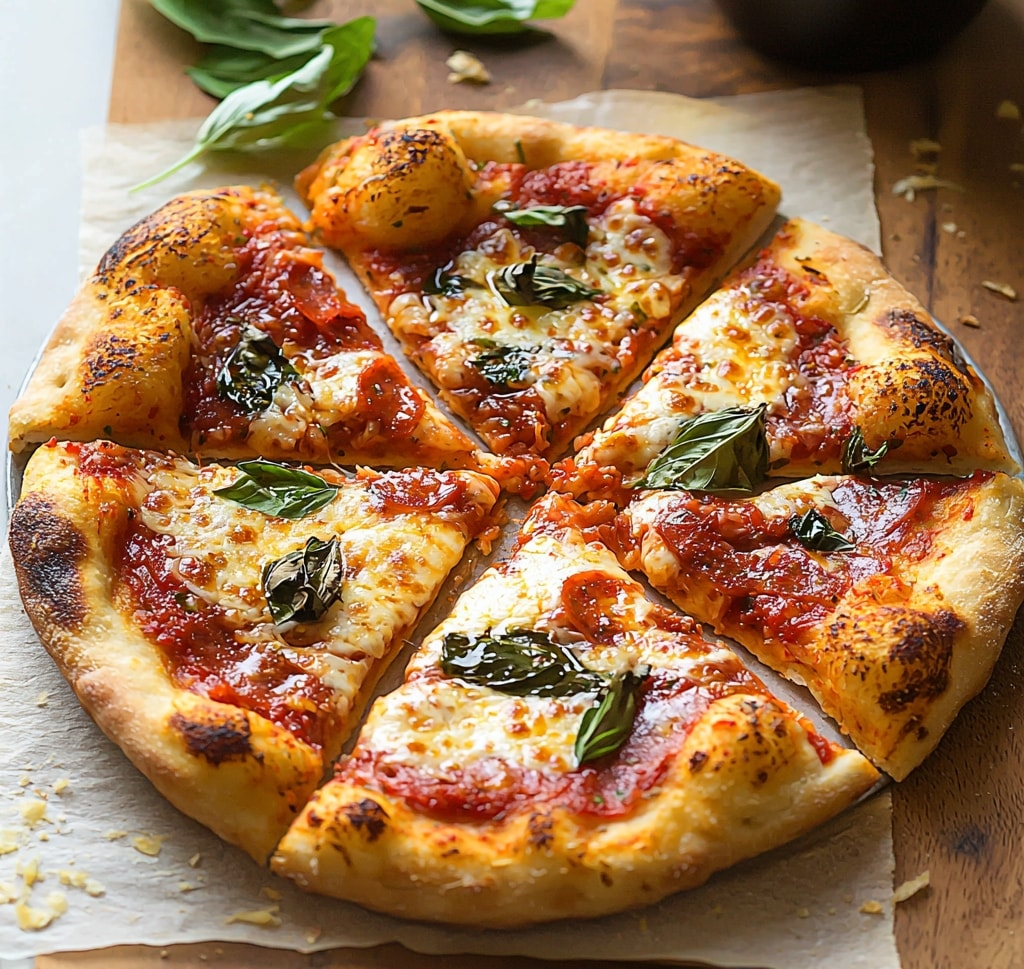

In [20]:
image_path = "images/pizza.png"
img = Image.open(image_path)
display(img)

## 3. Gerar Conteúdo Estruturado

Configuramos o modelo para responder obrigatoriamente seguindo o esquema `ImageAnalysis`.

In [21]:
model = genai.GenerativeModel('gemini-2.5-flash')

prompt = "Analise esta imagem detalhadamente, identificando os principais objetos e o contexto geral."

print("Processando imagem com output estruturado...")
response = model.generate_content(
    [prompt, img],
    generation_config=genai.GenerationConfig(
        response_mime_type="application/json",
        response_schema=ImageAnalysis
    )
)

# Converter e validar a resposta JSON usando o modelo Pydantic
try:
    data = json.loads(response.text)
    analysis = ImageAnalysis(**data)
    print("\n✅ Sucesso! Resposta validada.")
    print(json.dumps(data, indent=2, ensure_ascii=False))
except Exception as e:
    print(f"\n❌ Erro na extração/validação: {e}")
    print("Conteúdo bruto:", response.text)

Processando imagem com output estruturado...

✅ Sucesso! Resposta validada.
{
  "description": "Uma pizza Margherita recém-assada e apetitosa, cortada em seis fatias, repousando sobre papel manteiga em uma superfície de madeira. A pizza apresenta uma crosta dourada e crocante, molho de tomate vibrante, queijo mozzarella derretido e folhas frescas de manjericão espalhadas por cima. Algumas migalhas de queijo ou crosta estão visíveis na superfície de madeira, e folhas de manjericão adicionais adornam o fundo da imagem. Há um objeto escuro e desfocado parcialmente visível no canto superior direito.",
  "is_indoor": true,
  "lighting_rating": 5,
  "objects": [
    {
      "color": "vermelho, branco, verde, dourado",
      "estimated_size": "grande",
      "name": "pizza"
    },
    {
      "color": "vermelho, branco, verde, dourado",
      "estimated_size": "médio",
      "name": "fatia de pizza"
    },
    {
      "color": "verde",
      "estimated_size": "pequeno",
      "name": "manjeri

## 4. Trabalhando com Objetos Tipados

Agora temos acesso a todos os campos com autocompletar e validação.

In [22]:
print(f"📊 RESUMO DA ANÁLISE:")
print(f"- Descrição: {analysis.description}")
print(f"- Clima: {analysis.sentiment.value.capitalize()}")
print(f"- Ambiente: {'Interno' if analysis.is_indoor else 'Externo'}")
print(f"- Iluminação: {'⭐' * analysis.lighting_rating}")

print("\n🔍 OBJETOS ENCONTRADOS:")
for obj in analysis.objects:
    print(f"  • {obj.name} (Cor: {obj.color}, Tamanho: {obj.estimated_size})")

📊 RESUMO DA ANÁLISE:
- Descrição: Uma pizza Margherita recém-assada e apetitosa, cortada em seis fatias, repousando sobre papel manteiga em uma superfície de madeira. A pizza apresenta uma crosta dourada e crocante, molho de tomate vibrante, queijo mozzarella derretido e folhas frescas de manjericão espalhadas por cima. Algumas migalhas de queijo ou crosta estão visíveis na superfície de madeira, e folhas de manjericão adicionais adornam o fundo da imagem. Há um objeto escuro e desfocado parcialmente visível no canto superior direito.
- Clima: Positivo
- Ambiente: Interno
- Iluminação: ⭐⭐⭐⭐⭐

🔍 OBJETOS ENCONTRADOS:
  • pizza (Cor: vermelho, branco, verde, dourado, Tamanho: grande)
  • fatia de pizza (Cor: vermelho, branco, verde, dourado, Tamanho: médio)
  • manjericão (Cor: verde, Tamanho: pequeno)
  • queijo mozzarella (Cor: branco, Tamanho: médio)
  • molho de tomate (Cor: vermelho, Tamanho: médio)
  • papel manteiga (Cor: bege, Tamanho: grande)
  • superfície de madeira (Cor: marro